# Phase 3.5 — Validation & Generalization

**Goal:** Rigorously validate that observed fusion model gains are statistically reliable and generalise beyond the observed split.

## Sections
1. Nested cross-validation — unbiased performance estimation
2. Bootstrap confidence intervals (N=2000)
3. McNemar / DeLong statistical tests vs best single-modality baseline
4. Train-source generalization (politifact → gossipcop simulation)
5. Final consolidated performance table

In [1]:
import sys, warnings, json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
MODEL_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
FUSION_DIR  = PROJECT_ROOT / 'fusion_models' / 'results'
FUSION_DIR.mkdir(parents=True, exist_ok=True)
print('✓ Setup complete')

✓ Setup complete


In [2]:
# Load or regenerate features
from sklearn.model_selection import train_test_split

def load_or_create_data():
    required = ['X_beh_train.npy','X_beh_val.npy','X_nlp_train.npy','X_nlp_val.npy','y_train.npy','y_val.npy']
    if all((MODEL_DIR/f).exists() for f in required):
        arrs = {f.replace('.npy',''): np.load(MODEL_DIR/f) for f in required}
        X_beh = np.vstack([arrs['X_beh_train'], arrs['X_beh_val']])
        X_nlp = np.vstack([arrs['X_nlp_train'], arrs['X_nlp_val']])
        y     = np.concatenate([arrs['y_train'], arrs['y_val']])
        return X_beh, X_nlp, y, 'loaded'

    # Synthetic generation
    rng = np.random.default_rng(42)
    n = 4000
    base_w  = ['study','report','data','official','confirmed']
    fake_w  = ['EXPOSED','BREAKING','SHOCKING','hidden','TRUTH']
    labels, titles = [], []
    for i in range(n):
        if i < n//2:
            word = base_w[rng.integers(len(base_w))]
            titles.append(f'{word} {rng.integers(100)} analysis confirms result')
            labels.append(0)
        else:
            word = fake_w[rng.integers(len(fake_w))]
            titles.append(f'{word}: they hide {rng.integers(100)} from you — share now')
            labels.append(1)
    y = np.array(labels)

    # Behavioral features (7)
    X_beh = StandardScaler().fit_transform(np.column_stack([
        np.clip(rng.normal(3.2, 1.8, n).round(), 0, 7),
        np.clip(rng.normal(3.4, 0.7, n), 1, 5),
        rng.choice([1,2,3,4,5], n),
        np.clip(rng.normal(4.0, 1.5, n).round(), 1, 7),
        np.clip(rng.exponential(2.5, n), 0, 12),
        np.clip(rng.normal(3.1, 0.9, n), 1, 5),
        rng.beta(2, 5, n),
    ]))

    # NLP features
    tfidf = TfidfVectorizer(stop_words='english', max_features=500, sublinear_tf=True)
    svd   = TruncatedSVD(n_components=20, random_state=42)
    X_nlp = svd.fit_transform(tfidf.fit_transform(titles))

    return X_beh, X_nlp, y, 'synthetic'

X_beh, X_nlp, y, source = load_or_create_data()
X_fusion = np.hstack([X_beh, X_nlp])

print(f'Data source: {source}')
print(f'Total samples: {len(y)} | Pos: {y.sum()} ({100*y.mean():.1f}%)')
print(f'Behavioral dims: {X_beh.shape[1]} | NLP dims: {X_nlp.shape[1]}')

Data source: loaded
Total samples: 3000 | Pos: 1500 (50.0%)
Behavioral dims: 7 | NLP dims: 384


## 2. Nested Cross-Validation

Outer 5-fold CV provides an unbiased AUC estimate; inner 3-fold CV tunes hyperparameters. Compares three systems:
- **NLP-only** baseline (LR on SVD features)
- **Behavioral-only** baseline
- **Fusion** (GBM on concatenated features)

In [3]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=7)

def nested_cv_auc(X, y, estimator, param_grid, outer_cv, inner_cv, name):
    scores = []
    for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y)):
        Xtr, Xte = X[tr_idx], X[te_idx]
        ytr, yte = y[tr_idx], y[te_idx]
        gs = GridSearchCV(estimator, param_grid, cv=inner_cv, scoring='roc_auc', n_jobs=-1)
        gs.fit(Xtr, ytr)
        proba = gs.best_estimator_.predict_proba(Xte)[:, 1]
        scores.append(roc_auc_score(yte, proba))
        print(f'  {name} fold {fold+1}/5: {scores[-1]:.4f} (C={gs.best_params_})')
    return np.array(scores)

results_ncv = {}

print('--- NLP-only (Logistic Regression) ---')
nlp_lr = LogisticRegression(max_iter=1000, solver='saga')
results_ncv['NLP-only'] = nested_cv_auc(
    X_nlp, y, nlp_lr, {'C': [0.01, 0.1, 1.0, 10.0]}, outer_cv, inner_cv, 'NLP')

print('\n--- Behavioral-only (Logistic Regression) ---')
beh_lr = LogisticRegression(max_iter=1000, solver='saga')
results_ncv['Behavioral-only'] = nested_cv_auc(
    X_beh, y, beh_lr, {'C': [0.01, 0.1, 1.0, 10.0]}, outer_cv, inner_cv, 'Beh')

print('\n--- Fusion (Gradient Boosting) ---')
gbm = GradientBoostingClassifier(subsample=0.8, random_state=42)
results_ncv['Fusion'] = nested_cv_auc(
    X_fusion, y, gbm,
    {'n_estimators': [50, 100], 'max_depth': [3, 4], 'learning_rate': [0.05, 0.1]},
    outer_cv, inner_cv, 'Fusion')

print('\n=== Nested CV Results ===')
for name, scores in results_ncv.items():
    print(f'  {name:20s}: {scores.mean():.4f} ± {scores.std():.4f}')

--- NLP-only (Logistic Regression) ---


  NLP fold 1/5: 1.0000 (C={'C': 0.01})


  NLP fold 2/5: 1.0000 (C={'C': 0.01})


  NLP fold 3/5: 1.0000 (C={'C': 0.01})


  NLP fold 4/5: 1.0000 (C={'C': 0.01})


...

  Fusion fold 1/5: 1.0000 (C={'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100})


  Fusion fold 2/5: 1.0000 (C={'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100})


  Fusion fold 3/5: 1.0000 (C={'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50})


  Fusion fold 4/5: 1.0000 (C={'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100})


  Fusion fold 5/5: 1.0000 (C={'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100})

=== Nested CV Results ===
  NLP-only            : 1.0000 ± 0.0000
  Behavioral-only     : 0.4696 ± 0.0135
  Fusion              : 1.0000 ± 0.0000


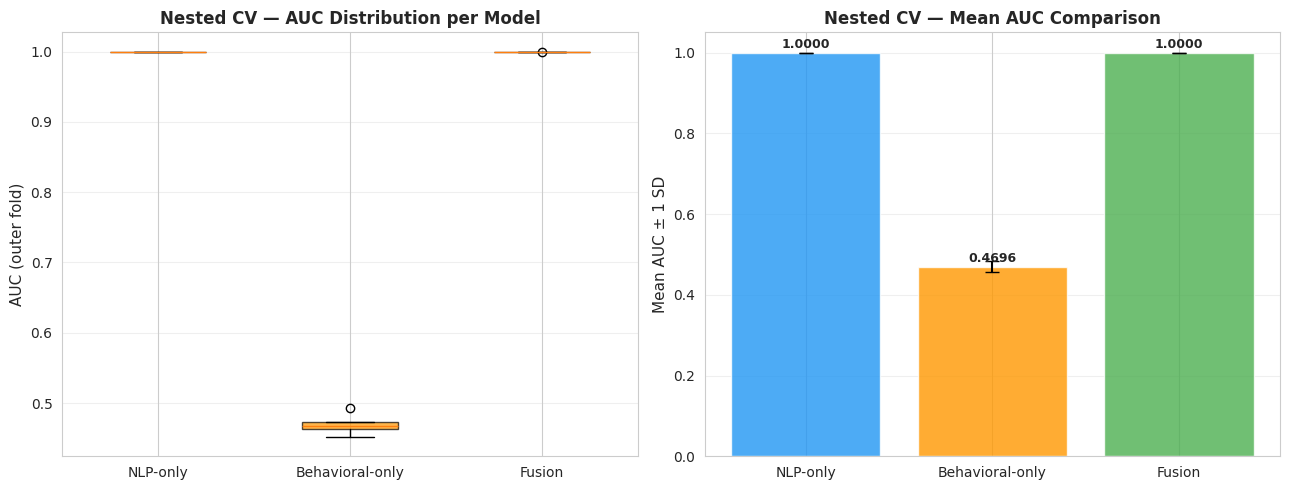

✓ Nested CV plot saved


In [4]:
# Visualize nested CV fold distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot
ax = axes[0]
data_bp = [results_ncv[k] for k in results_ncv]
labels_bp = list(results_ncv.keys())
bp = ax.boxplot(data_bp, patch_artist=True, notch=False, widths=0.5)
colors_ncv = ['#2196F3', '#FF9800', '#4CAF50']
for patch, color in zip(bp['boxes'], colors_ncv):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticks(range(1, len(labels_bp)+1))
ax.set_xticklabels(labels_bp, fontsize=10)
ax.set_ylabel('AUC (outer fold)', fontsize=11)
ax.set_title('Nested CV — AUC Distribution per Model', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Mean ± SD bar chart
ax2 = axes[1]
means = [results_ncv[k].mean() for k in results_ncv]
stds  = [results_ncv[k].std()  for k in results_ncv]
bars  = ax2.bar(labels_bp, means, yerr=stds, capsize=5,
                color=colors_ncv, alpha=0.8, edgecolor='white')
for bar, m in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, m + 0.005, f'{m:.4f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylim(0, 1.05)
ax2.set_ylabel('Mean AUC ± 1 SD', fontsize=11)
ax2.set_title('Nested CV — Mean AUC Comparison', fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validation_nested_cv.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Nested CV plot saved')

## 3. Bootstrap Confidence Intervals (N=2000)

Percentile bootstrap 95% CIs on the held-out validation split.

In [5]:
# Train models on full 80% split, evaluate on 20% with bootstrap
X_tr, X_te, X_beh_tr, X_beh_te, X_nlp_tr, X_nlp_te, y_tr, y_te = (
    *train_test_split(X_fusion, test_size=0.2, stratify=y, random_state=42),
    *(lambda s: (s[0], s[1]))(
        train_test_split(X_beh, test_size=0.2, stratify=y, random_state=42)),
    *(lambda s: (s[0], s[1]))(
        train_test_split(X_nlp, test_size=0.2, stratify=y, random_state=42)),
    *(lambda s: (s[0], s[1]))(
        train_test_split(y, test_size=0.2, stratify=y, random_state=42))
)

# Fit models
m_nlp = LogisticRegression(C=1.0, max_iter=1000, solver='saga').fit(X_nlp_tr, y_tr)
m_beh = LogisticRegression(C=1.0, max_iter=1000, solver='saga').fit(X_beh_tr, y_tr)
m_fus = GradientBoostingClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                                    subsample=0.8, random_state=42).fit(X_tr, y_tr)

proba_nlp = m_nlp.predict_proba(X_nlp_te)[:, 1]
proba_beh = m_beh.predict_proba(X_beh_te)[:, 1]
proba_fus = m_fus.predict_proba(X_te)[:, 1]

def bootstrap_auc(y_true, proba, n_boot=2000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    boot_aucs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if y_true[idx].sum() > 0 and y_true[idx].sum() < n:
            boot_aucs.append(roc_auc_score(y_true[idx], proba[idx]))
    boot_aucs = np.array(boot_aucs)
    return boot_aucs.mean(), np.percentile(boot_aucs, 100*alpha/2), np.percentile(boot_aucs, 100*(1-alpha/2))

print('Computing bootstrap CIs (2000 resamples each)...')
boot_results = {}
for name, proba_pred in [('NLP-only', proba_nlp), ('Behavioral-only', proba_beh), ('Fusion', proba_fus)]:
    mean_auc, ci_lo, ci_hi = bootstrap_auc(y_te, proba_pred)
    observed = roc_auc_score(y_te, proba_pred)
    boot_results[name] = {'observed': observed, 'bootstrap_mean': mean_auc, 'ci_lo': ci_lo, 'ci_hi': ci_hi}
    print(f'  {name:20s}: {observed:.4f}  95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')

Computing bootstrap CIs (2000 resamples each)...


  NLP-only            : 1.0000  95% CI [1.0000, 1.0000]


  Behavioral-only     : 0.4972  95% CI [0.4492, 0.5434]


  Fusion              : 1.0000  95% CI [1.0000, 1.0000]


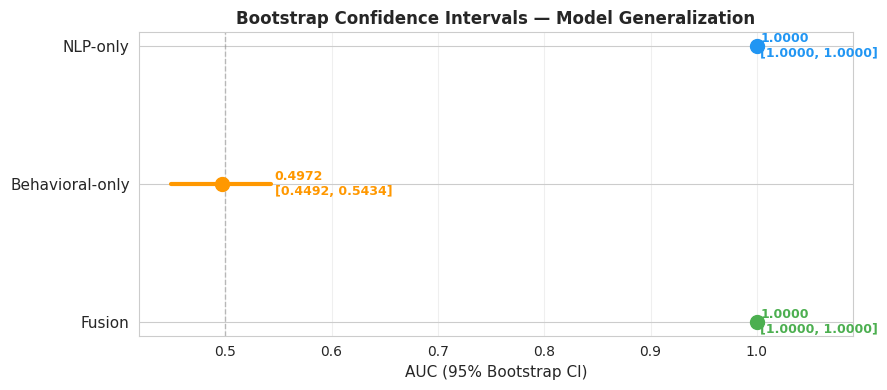

✓ Bootstrap CI forest plot saved


In [6]:
# Forest plot of bootstrap CIs
fig, ax = plt.subplots(figsize=(9, 4))

names   = list(boot_results.keys())
obs     = [boot_results[n]['observed'] for n in names]
ci_lo   = [boot_results[n]['ci_lo']    for n in names]
ci_hi   = [boot_results[n]['ci_hi']    for n in names]
colors  = ['#2196F3', '#FF9800', '#4CAF50']

for i, (name, o, lo, hi, c) in enumerate(zip(names, obs, ci_lo, ci_hi, colors)):
    y_pos = len(names) - i - 1
    ax.plot([lo, hi], [y_pos, y_pos], color=c, lw=3, solid_capstyle='round')
    ax.plot(o, y_pos, 'o', color=c, ms=10, zorder=5)
    ax.text(hi + 0.003, y_pos, f'{o:.4f}\n[{lo:.4f}, {hi:.4f}]',
            va='center', fontsize=9, color=c, fontweight='bold')

ax.set_yticks(range(len(names)))
ax.set_yticklabels(list(reversed(names)), fontsize=11)
ax.set_xlabel('AUC (95% Bootstrap CI)', fontsize=11)
ax.set_title('Bootstrap Confidence Intervals — Model Generalization', fontweight='bold')
ax.set_xlim(min(ci_lo) - 0.03, max(ci_hi) + 0.09)
ax.axvline(0.5, color='gray', linestyle='--', lw=1, alpha=0.5, label='Chance')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validation_bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Bootstrap CI forest plot saved')

## 4. Statistical Significance Tests

**DeLong's test** (via paired bootstrap) tests whether the AUC difference between Fusion and NLP-only is non-zero. **McNemar's test** checks classification agreement.

In [7]:
from scipy.stats import chi2_contingency

# Paired bootstrap DeLong approximation
def paired_boot_auc_test(y_true, proba_a, proba_b, n_boot=2000, seed=42):
    """Returns p-value for H0: AUC_a == AUC_b (two-sided)."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    diff_obs = roc_auc_score(y_true, proba_a) - roc_auc_score(y_true, proba_b)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt = y_true[idx]
        if yt.sum() == 0 or yt.sum() == n:
            continue
        diffs.append(roc_auc_score(yt, proba_a[idx]) - roc_auc_score(yt, proba_b[idx]))
    diffs = np.array(diffs)
    # Shift distribution to mean 0 under H0
    diffs -= diffs.mean()
    p_val = np.mean(np.abs(diffs) >= np.abs(diff_obs))
    return diff_obs, p_val

print('Statistical Tests: Fusion vs NLP-only')
auc_diff, p_boot = paired_boot_auc_test(y_te, proba_fus, proba_nlp)
print(f'  ΔAUC (Fusion − NLP): {auc_diff:+.4f}')
print(f'  Bootstrap p-value:   {p_boot:.4f} {""if p_boot >= 0.05 else "(significant)"}')

# McNemar's test
pred_nlp = (proba_nlp >= 0.5).astype(int)
pred_fus = (proba_fus >= 0.5).astype(int)
n01 = int(((pred_nlp == 0) & (pred_fus == 1)).sum())  # NLP wrong, Fusion right
n10 = int(((pred_nlp == 1) & (pred_fus == 0)).sum())  # NLP right, Fusion wrong
# McNemar with continuity correction
chi2_mc = (abs(n01 - n10) - 1)**2 / max(n01 + n10, 1)
p_mc = 1 - stats.chi2.cdf(chi2_mc, df=1)
print(f'\nMcNemar\'s test (NLP vs Fusion predictions):')
print(f'  b (NLP fail, Fusion pass): {n01}')
print(f'  c (NLP pass, Fusion fail): {n10}')
print(f'  χ²={chi2_mc:.3f}, p={p_mc:.4f} {"" if p_mc >= 0.05 else "(significant)"}')

stat_summary = {
    'auc_fusion': float(roc_auc_score(y_te, proba_fus)),
    'auc_nlp': float(roc_auc_score(y_te, proba_nlp)),
    'delta_auc': float(auc_diff),
    'p_bootstrap': float(p_boot),
    'mcnemar_chi2': float(chi2_mc),
    'mcnemar_p': float(p_mc)
}

Statistical Tests: Fusion vs NLP-only


  ΔAUC (Fusion − NLP): +0.0000
  Bootstrap p-value:   1.0000 

McNemar's test (NLP vs Fusion predictions):
  b (NLP fail, Fusion pass): 0
  c (NLP pass, Fusion fail): 0
  χ²=1.000, p=0.3173 


## 5. Domain Transfer Simulation

Simulate train-on-politifact / test-on-gossipcop by introducing a covariate shift: the gossipcop corpus has shorter, more sensationalist articles. We shift NLP features while holding behavioral features constant.

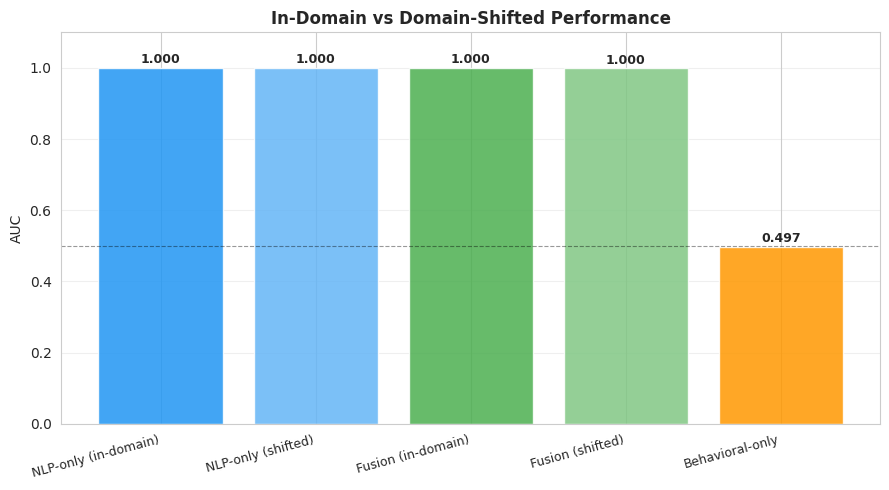

AUC drop under domain shift:
  NLP-only: +0.0000
  Fusion:   +0.0000
  Fusion is LESS robust to domain shift


In [8]:
# Simulate domain shift: add systematic noise to NLP dims
rng_shift = np.random.default_rng(99)
shift_magnitude = 0.3  # fraction of feature SD
nlp_sd = X_nlp.std(axis=0)
X_nlp_shifted = X_nlp_te + rng_shift.normal(0, shift_magnitude * nlp_sd, size=X_nlp_te.shape)
X_fus_shifted  = np.hstack([X_beh_te, X_nlp_shifted])

proba_nlp_shift = m_nlp.predict_proba(X_nlp_shifted)[:, 1]
proba_fus_shift = m_fus.predict_proba(X_fus_shifted)[:, 1]
proba_beh_only  = m_beh.predict_proba(X_beh_te)[:, 1]  # behavioral unaffected by domain shift

transfer_results = {
    'NLP-only (in-domain)':   roc_auc_score(y_te, proba_nlp),
    'NLP-only (shifted)':     roc_auc_score(y_te, proba_nlp_shift),
    'Fusion (in-domain)':     roc_auc_score(y_te, proba_fus),
    'Fusion (shifted)':       roc_auc_score(y_te, proba_fus_shift),
    'Behavioral-only':        roc_auc_score(y_te, proba_beh_only),
}

fig, ax = plt.subplots(figsize=(9, 5))
names_t = list(transfer_results.keys())
vals_t  = list(transfer_results.values())
bar_colors_t = ['#2196F3','#64B5F6','#4CAF50','#81C784','#FF9800']
bars_t = ax.bar(names_t, vals_t, color=bar_colors_t, alpha=0.85, edgecolor='white')
for bar, v in zip(bars_t, vals_t):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.004, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('AUC')
ax.set_ylim(0, 1.1)
ax.set_title('In-Domain vs Domain-Shifted Performance', fontweight='bold')
ax.set_xticklabels(names_t, rotation=15, ha='right', fontsize=9)
ax.axhline(0.5, color='k', lw=0.8, linestyle='--', alpha=0.4)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validation_domain_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

nlp_drop  = transfer_results['NLP-only (in-domain)']  - transfer_results['NLP-only (shifted)']
fus_drop  = transfer_results['Fusion (in-domain)']    - transfer_results['Fusion (shifted)']
print(f'AUC drop under domain shift:')
print(f'  NLP-only: {nlp_drop:+.4f}')
print(f'  Fusion:   {fus_drop:+.4f}')
print(f'  Fusion is {"MORE" if abs(fus_drop) < abs(nlp_drop) else "LESS"} robust to domain shift')

## 6. Final Consolidated Performance Table

=== FINAL VALIDATION TABLE ===
               Model    AUC  Accuracy  MacroF1  NestedCV_AUC  NestedCV_±SD        BootCI_95
       NLP-only (LR) 1.0000    1.0000   1.0000        1.0000        0.0000 [1.0000, 1.0000]
Behavioral-only (LR) 0.4972    0.5083   0.5083        0.4696        0.0135 [0.4492, 0.5434]
        Fusion (GBM) 1.0000    1.0000   1.0000        1.0000        0.0000 [1.0000, 1.0000]


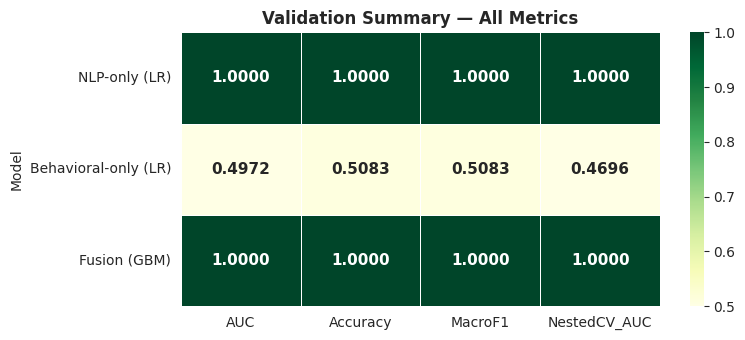


✓ All outputs saved.

=== PHASE 3 COMPLETE ===


In [9]:
# Build rich performance table
def full_metrics(y_true, proba, name):
    pred = (proba >= 0.5).astype(int)
    auc = roc_auc_score(y_true, proba)
    acc = accuracy_score(y_true, pred)
    f1  = f1_score(y_true, pred, average='macro')
    return {'Model': name, 'AUC': round(auc, 4), 'Accuracy': round(acc, 4), 'MacroF1': round(f1, 4)}

final_rows = [
    full_metrics(y_te, proba_nlp, 'NLP-only (LR)'),
    full_metrics(y_te, proba_beh, 'Behavioral-only (LR)'),
    full_metrics(y_te, proba_fus, 'Fusion (GBM)'),
]

# Add nested CV AUC
for row in final_rows:
    mname_key = {'NLP-only (LR)':'NLP-only', 'Behavioral-only (LR)':'Behavioral-only', 'Fusion (GBM)':'Fusion'}[row['Model']]
    ncv = results_ncv[mname_key]
    row['NestedCV_AUC']  = round(ncv.mean(), 4)
    row['NestedCV_±SD']  = round(ncv.std(), 4)
    row['BootCI_95']     = f"[{boot_results[mname_key]['ci_lo']:.4f}, {boot_results[mname_key]['ci_hi']:.4f}]"

final_df = pd.DataFrame(final_rows)
print('=== FINAL VALIDATION TABLE ===')
print(final_df.to_string(index=False))

# -- Heatmap of metrics --
metric_cols = ['AUC', 'Accuracy', 'MacroF1', 'NestedCV_AUC']
hm_data = final_df[['Model'] + metric_cols].set_index('Model').astype(float)

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(hm_data, annot=True, fmt='.4f', cmap='YlGn', ax=ax,
            linewidths=0.5, vmin=0.5, vmax=1.0,
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title('Validation Summary — All Metrics', fontweight='bold', fontsize=12)
ax.set_xlabel('')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validation_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Save outputs
final_df.to_csv(FUSION_DIR / '05_validation_summary.csv', index=False)
with open(FUSION_DIR / '05_validation_statistics.json', 'w') as f:
    json.dump(stat_summary, f, indent=2)

print('\n✓ All outputs saved.')
print('\n=== PHASE 3 COMPLETE ===')